# Jalkapallon ennustemalli — koko putki

**Korjattu versio** — sarakenimet vastaavat oikeita soccerdata-tuotoksia.

## 0. Asetukset

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 100

import config

## 1. FBref-pohjadata

In [2]:
from src.data.fbref import lataa_otteludata, lataa_joukkueen_kausistatistiikka, vie_csv

LIIGAT = ['ENG-Premier League']
KAUDET = ['2324', '2425', '2526']

ottelut = lataa_otteludata(LIIGAT, KAUDET, cache_dir=config.RAW_DATA_DIR / 'fbref')
print(f'Haettiin {len(ottelut)} ottelua')
ottelut.head()

[04/26/26 17:35:46] INFO     No custom team name replacements found. You can configure these in       ]8;id=6298495;file://C:\Users\vvsaa\Documents\football-prediction\.venv\Lib\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=6298496;file://C:\Users\vvsaa\Documents\football-prediction\.venv\Lib\site-packages\soccerdata\_config.py#92\92]8;;\
                             C:\Users\vvsaa\soccerdata\config\teamname_replacements.json.                          

                    INFO     No custom league dict found. You can configure additional leagues in    ]8;id=6298502;file://C:\Users\vvsaa\Documents\football-prediction\.venv\Lib\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=6298503;file://C:\Users\vvsaa\Documents\football-prediction\.venv\Lib\site-packages\soccerdata\_config.py#190\190]8;;\
                             C:\Users\vvsaa\soccerdata\config\league_dict.json.                                    

                    INFO     Saving cached data to                                                   ]8;id=6298510;file://C:\Users\vvsaa\Documents\football-prediction\.venv\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=6298511;file://C:\Users\vvsaa\Documents\football-prediction\.venv\Lib\site-packages\soccerdata\_common.py#250\250]8;;\
                             C:\Users\vvsaa\Documents\football-prediction\data\raw\fbref                           

Haettiin 1140 ottelua


,league,season,game,week,day,date,time,home_team,score,away_team,attendance,venue,referee,match_report,notes,game_id
0,ENG-Premier League,2324,2023-08-11 Burnley-Manchester City,1,Fri,2023-08-11,20:00 (22:00),Burnley,0–3,Manchester City,21572,Turf Moor,Craig Pawson,/en/matches/3a6836b4/Burnley-Manchester-City-A...,<NA>,3a6836b4
1,ENG-Premier League,2324,2023-08-12 Arsenal-Nottingham Forest,1,Sat,2023-08-12,12:30 (14:30),Arsenal,2–1,Nottingham Forest,59984,Emirates Stadium,Michael Oliver,/en/matches/26a7f90c/Arsenal-Nottingham-Forest...,<NA>,26a7f90c
2,ENG-Premier League,2324,2023-08-12 Bournemouth-West Ham United,1,Sat,2023-08-12,15:00 (17:00),Bournemouth,1–1,West Ham United,11245,Vitality Stadium,Peter Bankes,/en/matches/d6bbf293/Bournemouth-West-Ham-Unit...,<NA>,d6bbf293
3,ENG-Premier League,2324,2023-08-12 Brighton-Luton Town,1,Sat,2023-08-12,15:00 (17:00),Brighton,4–1,Luton Town,31872,The American Express Community Stadium,David Coote,/en/matches/56a137f7/Brighton-and-Hove-Albion-...,<NA>,56a137f7
4,ENG-Premier League,2324,2023-08-12 Everton-Fulham,1,Sat,2023-08-12,15:00 (17:00),Everton,0–1,Fulham,39940,Goodison Park,Stuart Attwell,/en/matches/15addfc7/Everton-Fulham-August-12-...,<NA>,15addfc7


In [3]:
vie_csv(ottelut, config.PROCESSED_DATA_DIR / 'pl_ottelut.csv')
print('CSV tallennettu')

CSV tallennettu


## 2. Understat — xG-trendit

In [4]:
from src.data.understat import lataa_otteludata as lataa_us_ottelut
from src.data.understat import lataa_laukaukset, joukkueen_xg_aikasarja

us_ottelut = lataa_us_ottelut(['ENG-Premier League'], ['2425', '2526'],
                              cache_dir=config.RAW_DATA_DIR / 'understat')
print('Sarakkeet:', list(us_ottelut.columns))
us_ottelut.head()

[04/26/26 17:36:06] INFO     Saving cached data to                                                   ]8;id=6298516;file://C:\Users\vvsaa\Documents\football-prediction\.venv\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=6298517;file://C:\Users\vvsaa\Documents\football-prediction\.venv\Lib\site-packages\soccerdata\_common.py#250\250]8;;\
                             C:\Users\vvsaa\Documents\football-prediction\data\raw\understat                       

[2026-04-26 17:36:06] INFO     TLSLibrary:_load_library:397 - Successfully loaded TLS library: C:\Users\vvsaa\Documents\football-prediction\.venv\Lib\site-packages\tls_requests\bin\tls-client-xgo-1.13.1-windows-amd64.dll


                    INFO     Successfully loaded TLS library:                                      ]8;id=6298524;file://C:\Users\vvsaa\Documents\football-prediction\.venv\Lib\site-packages\tls_requests\models\libraries.py\libraries.py]8;;\:]8;id=6298525;file://C:\Users\vvsaa\Documents\football-prediction\.venv\Lib\site-packages\tls_requests\models\libraries.py#397\397]8;;\
                             C:\Users\vvsaa\Documents\football-prediction\.venv\Lib\site-packages\                 
                             tls_requests\bin\tls-client-xgo-1.13.1-windows-amd64.dll                              

Sarakkeet: ['league', 'season', 'game', 'league_id', 'season_id', 'game_id', 'date', 'home_team_id', 'away_team_id', 'home_team', 'away_team', 'away_team_code', 'home_team_code', 'home_goals', 'away_goals', 'home_xg', 'away_xg', 'is_result', 'has_data', 'url']


,league,season,game,league_id,season_id,game_id,date,home_team_id,away_team_id,home_team,away_team,away_team_code,home_team_code,home_goals,away_goals,home_xg,away_xg,is_result,has_data,url
0,ENG-Premier League,2425,2024-08-16 Manchester United-Fulham,1,2024,26602,2024-08-16 19:00:00,89,228,Manchester United,Fulham,FLH,MUN,1,0,2.04268,0.418711,True,True,https://understat.com/match/26602
1,ENG-Premier League,2425,2024-08-17 Arsenal-Wolverhampton Wanderers,1,2024,26604,2024-08-17 14:00:00,83,229,Arsenal,Wolverhampton Wanderers,WOL,ARS,2,0,1.6283,0.575835,True,True,https://understat.com/match/26604
2,ENG-Premier League,2425,2024-08-17 Everton-Brighton,1,2024,26605,2024-08-17 14:00:00,72,220,Everton,Brighton,BRI,EVE,0,3,0.405325,1.79083,True,True,https://understat.com/match/26605
3,ENG-Premier League,2425,2024-08-17 Ipswich-Liverpool,1,2024,26603,2024-08-17 11:30:00,285,87,Ipswich,Liverpool,LIV,IPS,0,2,0.342601,3.92906,True,True,https://understat.com/match/26603
4,ENG-Premier League,2425,2024-08-17 Newcastle United-Southampton,1,2024,26606,2024-08-17 14:00:00,86,74,Newcastle United,Southampton,SOU,NEW,1,0,0.433489,1.95483,True,True,https://understat.com/match/26606


In [5]:
laukaukset = lataa_laukaukset(['ENG-Premier League'], ['2425', '2526'],
                              cache_dir=config.RAW_DATA_DIR / 'understat')
print(f'Haettiin {len(laukaukset):,} laukausta')
laukaukset.head()

                    INFO     Saving cached data to                                                   ]8;id=6298530;file://C:\Users\vvsaa\Documents\football-prediction\.venv\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=6298531;file://C:\Users\vvsaa\Documents\football-prediction\.venv\Lib\site-packages\soccerdata\_common.py#250\250]8;;\
                             C:\Users\vvsaa\Documents\football-prediction\data\raw\understat                       

Haettiin 18,277 laukausta


,league,season,game,team,player,league_id,season_id,game_id,date,shot_id,team_id,player_id,assist_player_id,assist_player,xg,location_x,location_y,minute,body_part,situation,result
0,ENG-Premier League,2425,2024-08-16 Manchester United-Fulham,Fulham,Adama Traoré,1,2024,26602,2024-08-16 19:00:00,584627,228,900,666195,Rodrigo Muniz,0.036473,0.867,0.278,7,Right Foot,Open Play,Missed Shot
1,ENG-Premier League,2425,2024-08-16 Manchester United-Fulham,Fulham,Adama Traoré,1,2024,26602,2024-08-16 19:00:00,584644,228,900,666191,Sasa Lukic,0.057856,0.809,0.512,70,Right Foot,Open Play,Blocked Shot
2,ENG-Premier League,2425,2024-08-16 Manchester United-Fulham,Fulham,Adama Traoré,1,2024,26602,2024-08-16 19:00:00,584645,228,900,666190,Andreas Pereira,0.020298,0.758,0.361,71,Right Foot,Open Play,Blocked Shot
3,ENG-Premier League,2425,2024-08-16 Manchester United-Fulham,Fulham,Alex Iwobi,1,2024,26602,2024-08-16 19:00:00,584636,228,500,666190,Andreas Pereira,0.018718,0.962,0.628,47,<NA>,From Corner,Missed Shot
4,ENG-Premier League,2425,2024-08-16 Manchester United-Fulham,Fulham,Calvin Bassey,1,2024,26602,2024-08-16 19:00:00,584646,228,11728,666195,Rodrigo Muniz,0.034208,0.823,0.572,75,Left Foot,From Corner,Blocked Shot


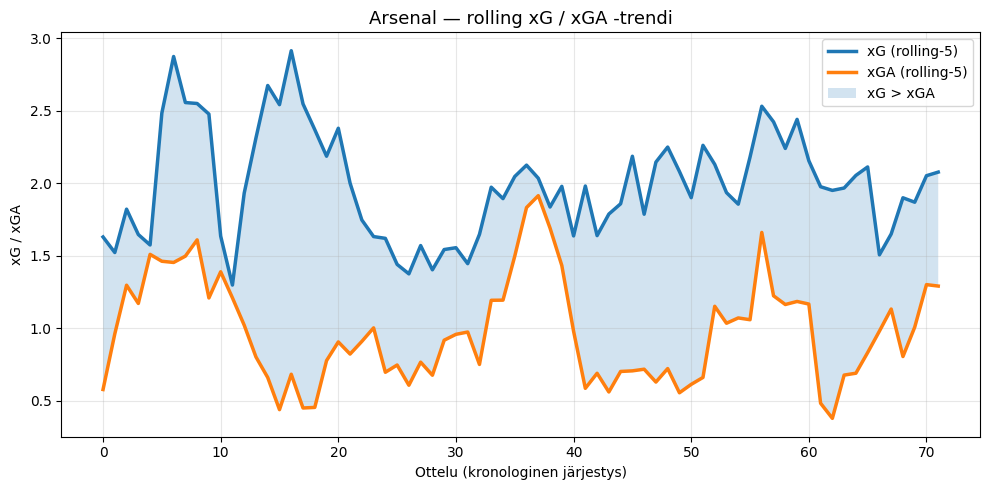

In [6]:
from src.viz.xg_plots import plot_rolling_xg

JOUKKUE = 'Arsenal'
aikasarja = joukkueen_xg_aikasarja(laukaukset, JOUKKUE)
fig, ax = plt.subplots(figsize=(10, 5))
plot_rolling_xg(aikasarja, JOUKKUE, ikkuna=5, ax=ax)
plt.tight_layout()
plt.show()

## 3. StatsBomb

In [7]:
from src.data.statsbomb import listaa_kilpailut, hae_ottelut, hae_tapahtumat, laske_xg_per_joukkue

kilpailut = listaa_kilpailut()
kilpailut.head(10)

[04/26/26 17:36:10] WARNING  C:\Users\vvsaa\Documents\football-prediction\.venv\Lib\site-packag ]8;id=6298538;file://C:\Users\vvsaa\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py\_py_warnings.py]8;;\:]8;id=6298539;file://C:\Users\vvsaa\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py#230\230]8;;\
                             es\statsbombpy\api_client.py:21: NoAuthWarning: credentials were                      
                             not supplied. open data access only                                                   
                               warnings.warn(                                                                      
                                                                                                                   

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,NaN,NaN,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,NaN,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882
5,16,2,Europe,Champions League,male,False,False,2016/2017,2024-02-13T02:37:32.205154,2021-06-13T16:17:31.694,NaN,2024-02-13T02:37:32.205154
6,16,27,Europe,Champions League,male,False,False,2015/2016,2024-06-12T07:45:38.786894,2021-06-13T16:17:31.694,NaN,2024-06-12T07:45:38.786894
7,16,26,Europe,Champions League,male,False,False,2014/2015,2024-02-12T12:49:54.914228,2021-06-13T16:17:31.694,NaN,2024-02-12T12:49:54.914228
8,16,25,Europe,Champions League,male,False,False,2013/2014,2024-02-12T12:48:48.479157,2021-06-13T16:17:31.694,NaN,2024-02-12T12:48:48.479157
9,16,24,Europe,Champions League,male,False,False,2012/2013,2024-02-12T12:47:34.340413,2021-06-13T16:17:31.694,NaN,2024-02-12T12:47:34.340413


In [8]:
mm_ottelut = hae_ottelut(competition_id=43, season_id=106)
finaali = mm_ottelut.sort_values('match_date').iloc[-1]
print('Finaali:', finaali['home_team'], 'vs', finaali['away_team'])
events = hae_tapahtumat(match_id=finaali['match_id'])
print(f'{len(events):,} tapahtumaa')
laske_xg_per_joukkue(events)

[04/26/26 17:36:11] WARNING  C:\Users\vvsaa\Documents\football-prediction\.venv\Lib\site-packag ]8;id=6298544;file://C:\Users\vvsaa\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py\_py_warnings.py]8;;\:]8;id=6298545;file://C:\Users\vvsaa\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py#230\230]8;;\
                             es\statsbombpy\api_client.py:21: NoAuthWarning: credentials were                      
                             not supplied. open data access only                                                   
                               warnings.warn(                                                                      
                                                                                                                   

Finaali: Argentina vs France
4,407 tapahtumaa


,team,shots,xG,goals
0,Argentina,24,5.892306,7
1,France,14,5.406618,5


## 4. Piirteiden rakentaminen

Understat: `home_goals`/`away_goals` -> nimetään `home_score`/`away_score`.

In [9]:
from src.features.team_features import (
    laajenna_per_joukkue, rolling_keskiarvo, yhdista_ottelutasolle,
    lisaa_1x2, lisaa_total_goals
)

us_ottelut_clean = us_ottelut.rename(columns={
    'home_goals': 'home_score',
    'away_goals': 'away_score',
}).copy()
us_ottelut_clean = us_ottelut_clean.dropna(subset=['home_score', 'away_score'])
us_ottelut_clean['date'] = pd.to_datetime(us_ottelut_clean['date'])

joukkue_ottelu = laajenna_per_joukkue(us_ottelut_clean)
joukkue_ottelu['xg_for'] = np.where(
    joukkue_ottelu['is_home'] == 1, joukkue_ottelu['home_xg'], joukkue_ottelu['away_xg'])
joukkue_ottelu['xg_against'] = np.where(
    joukkue_ottelu['is_home'] == 1, joukkue_ottelu['away_xg'], joukkue_ottelu['home_xg'])

piirteet = ['goals_for', 'goals_against', 'xg_for', 'xg_against']
joukkue_ottelu = rolling_keskiarvo(joukkue_ottelu, piirteet, ikkuna=5)

rolling_sarakkeet = [f'{p}_rolling5' for p in piirteet]
ottelutaso = yhdista_ottelutasolle(joukkue_ottelu, rolling_sarakkeet)
ottelutaso = lisaa_1x2(ottelutaso)
ottelutaso = lisaa_total_goals(ottelutaso)
ottelutaso.head()

,date,home_team,away_team,home_goals_for_rolling5,home_goals_against_rolling5,home_xg_for_rolling5,home_xg_against_rolling5,home_score,away_score,away_goals_for_rolling5,away_goals_against_rolling5,away_xg_for_rolling5,away_xg_against_rolling5,result_1x2,total_goals,btts
0,2024-08-17 14:00:00,Arsenal,Wolverhampton Wanderers,NaN,NaN,NaN,NaN,2,0,1.25,0.75,1.103818,1.436322,0,2,0
1,2024-08-31 11:30:00,Arsenal,Brighton,2.0,0.0,1.521145,0.946238,1,1,1.75,0.75,1.624400,0.919628,1,2,1
2,2024-09-28 14:00:00,Arsenal,Leicester,1.6,0.6,1.573056,1.451686,4,2,1.20,1.60,1.129537,2.048942,0,6,1
3,2024-10-05 14:00:00,Arsenal,Southampton,2.0,1.0,2.458006,1.404101,3,1,0.60,2.20,1.362442,2.568328,0,4,1
4,2024-10-27 16:30:00,Arsenal,Liverpool,2.0,1.4,2.490094,1.468741,2,2,1.60,0.60,2.004696,0.951354,1,4,1


## 5. Dixon-Coles -malli

In [10]:
from src.models.dixon_coles import DixonColesModel

treenidata = us_ottelut_clean.dropna(subset=['home_score', 'away_score']).copy()

malli = DixonColesModel().fit(
    treenidata,
    home_team_col='home_team',
    away_team_col='away_team',
    home_goals_col='home_score',
    away_goals_col='away_score',
    decay=0.0065,
    date_col='date',
)
print(f'Kotietu (gamma): {malli.home_advantage:.3f}')
print(f'Rho-korjaus: {malli.rho:.3f}')
print('\nVahvimmat hyokkaysreitingit:')
for joukkue, attack in sorted(malli.attack.items(), key=lambda x: -x[1])[:5]:
    print(f'  {joukkue}: {attack:.3f}')

Kotietu (gamma): 0.148
Rho-korjaus: -0.117

Vahvimmat hyokkaysreitingit:
  Manchester City: 0.412
  Arsenal: 0.373
  Liverpool: 0.359
  Manchester United: 0.285
  Bournemouth: 0.196


In [11]:
KOTI = 'Manchester City'
VIERAS = 'Arsenal'

lam, mu = malli.expected_goals(KOTI, VIERAS)
print(f'Odotetut maalit: {KOTI} {lam:.2f} - {mu:.2f} {VIERAS}\n')

print('1X2-todennakoisyydet:')
for k, v in malli.predict_1x2(KOTI, VIERAS).items():
    print(f'  {k:6s} {v:.3f}')

print('\nOver/Under 2.5:')
for k, v in malli.predict_over_under(KOTI, VIERAS, line=2.5).items():
    print(f'  {k:6s} {v:.3f}')

print('\nBTTS:')
for k, v in malli.predict_btts(KOTI, VIERAS).items():
    print(f'  {k:10s} {v:.3f}')

print('\nTodennakoisimmat tulokset:')
for tulos, p in malli.todennakoisin_tulos(KOTI, VIERAS, top_n=5):
    print(f'  {tulos}: {p:.3f}')

Odotetut maalit: Manchester City 1.25 - 1.05 Arsenal

1X2-todennakoisyydet:
  home   0.394
  draw   0.313
  away   0.294

Over/Under 2.5:
  over   0.404
  under  0.596
  push   -0.000

BTTS:
  btts_yes   0.479
  btts_no    0.521

Todennakoisimmat tulokset:
  1-1: 0.147
  0-0: 0.116
  1-0: 0.110
  0-1: 0.090
  2-1: 0.082


## 6. LightGBM

In [12]:
from src.models.outcome_model import opeta_1x2
from sklearn.metrics import log_loss, accuracy_score

feature_cols = [c for c in ottelutaso.columns if 'rolling5' in c]
data = ottelutaso.dropna(subset=feature_cols).copy().sort_values('date')

split = int(len(data) * 0.8)
train, valid = data.iloc[:split], data.iloc[split:]

X_train, y_train = train[feature_cols], train['result_1x2']
X_valid, y_valid = valid[feature_cols], valid['result_1x2']

lgb_1x2 = opeta_1x2(X_train, y_train, X_valid, y_valid)
ennusteet = lgb_1x2.predict(X_valid)
print(f'Log loss: {log_loss(y_valid, ennusteet):.3f}')
print(f'Accuracy: {accuracy_score(y_valid, ennusteet.argmax(axis=1)):.3f}')

Log loss: 1.078
Accuracy: 0.431


## 7. SofaScore live (voi 403:n vuoksi epaonnistua)

In [13]:
from src.data.sofascore import hae_live_ottelut, parsi_live_ottelut

try:
    events = hae_live_ottelut()
    live = parsi_live_ottelut(events)
    print(f'Kaynnissa {len(live)} ottelua')
    display(live.head(10))
except Exception as e:
    print(f'SofaScore epaonnistui: {e}')
    print('Yleinen ongelma — SofaScore blokkaa pyynnot kovin helposti.')

SofaScore epaonnistui: 403 Client Error: Forbidden for url: https://api.sofascore.com/api/v1/sport/football/events/live
Yleinen ongelma — SofaScore blokkaa pyynnot kovin helposti.
